# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import kagglehub
# from keras.preprocessing.image import ImageDataGenerator
from keras.utils import image_dataset_from_directory

import tensorflow as tf
from keras.models import Sequential
from keras import layers
from keras.layers import Dense,Conv2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Data Loading and Data Engineering

In [ ]:
path = kagglehub.dataset_download("pacificrm/skindiseasedataset")
print(path)

Using Colab cache for faster access to the 'skindiseasedataset' dataset.
/kaggle/input/skindiseasedataset


In [ ]:
# Extracting paths by keep driling
os.listdir(path)
path1 = os.path.join(path, 'SkinDisease')
print(path1)

os.listdir(path1)
path2 = os.path.join(path1, 'SkinDisease')
os.listdir(path2)
print(path2)

print(os.listdir(path2))

train_path = os.path.join(path2, 'train')
test_path = os.path.join(path2, 'test')

/kaggle/input/skindiseasedataset/SkinDisease
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease
['test', 'train']


In [ ]:
# using modern API image_dataset_from_directory

train_datasets = image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    # shuffle=True,
    seed=42,
    label_mode='categorical'
)
test_datasets = image_dataset_from_directory(
    test_path,
    image_size=(224, 224), # for efficent net model
    batch_size=32,
    # shuffle=True,  not
    seed=42,
    label_mode='categorical'
)

Found 13898 files belonging to 22 classes.
Found 1546 files belonging to 22 classes.


In [ ]:
train_datasets

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 22), dtype=tf.float32, name=None))>

In [ ]:
# save the class names
class_names = train_datasets.class_names
print(class_names)

['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


In [ ]:
# Scale the value
train_ds = train_datasets.map(lambda x, y: (x/255.0, y))
test_ds = test_datasets.map(lambda x, y: (x/255.0, y))


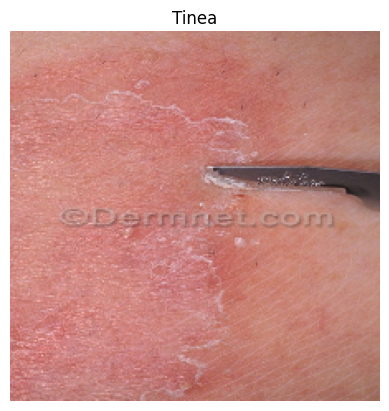

In [ ]:
for images, labels in train_ds.take(1):  # 32 images (batch images)
    # print(labels[0])
    plt.imshow(images[30].numpy().astype('float32'))
    index = np.argmax(labels[30])
    label_name = class_names[index]
    plt.title(label_name)
    plt.axis('off')
    plt.show()

# Build CNN custom model

In [ ]:
# skin_cnn_model = Sequential([

# ])

# Load the Pre-Trained Model

In [ ]:
from keras.applications import EfficientNetV2B3, DenseNet121

In [ ]:
base_model = DenseNet121(weights='imagenet', include_top=False,)
base_model.summary()


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, None,      │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d_4… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
# freeze base model, fite tuning.
base_model.trainable = True
for layer in base_model.layers[:-10]: #all layers except last 10 layers
    layer.trainable = False

new_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(len(class_names), activation='softmax')

    ])

new_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, None, None,     │     7,037,504 │
│                                 │ 1024)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,171,542 (27.36 MB)

 Trainable params: 302,166 (1.15 MB)

 Non-trainable params: 6,869,376 (26.20 MB)

In [ ]:
early_stopper = EarlyStopping(patience=3,
                              monitor='val_loss',
                              restore_best_weights=True,
                              verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss',
                               patience=3,
                               factor=0.5,
                               restore_best_weights=True,
                               verbose=1
                               )

In [ ]:
# Compile the model
new_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# fit the model
history = new_model.fit(
    train_ds,
    batch_size=64,
    epochs=5,
    validation_data=test_ds,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)


Epoch 1/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 130s 229ms/step - accuracy: 0.3839 - loss: 2.0472 - val_accuracy: 0.4741 - val_loss: 1.7414 - learning_rate: 0.0010
Epoch 2/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 63s 145ms/step - accuracy: 0.5168 - loss: 1.5793 - val_accuracy: 0.5013 - val_loss: 1.5751 - learning_rate: 0.0010
Epoch 3/5
434/435 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5690 - loss: 1.3744
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
435/435 ━━━━━━━━━━━━━━━━━━━━ 64s 147ms/step - accuracy: 0.5754 - loss: 1.3528 - val_accuracy: 0.5246 - val_loss: 1.5778 - learning_rate: 0.0010
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


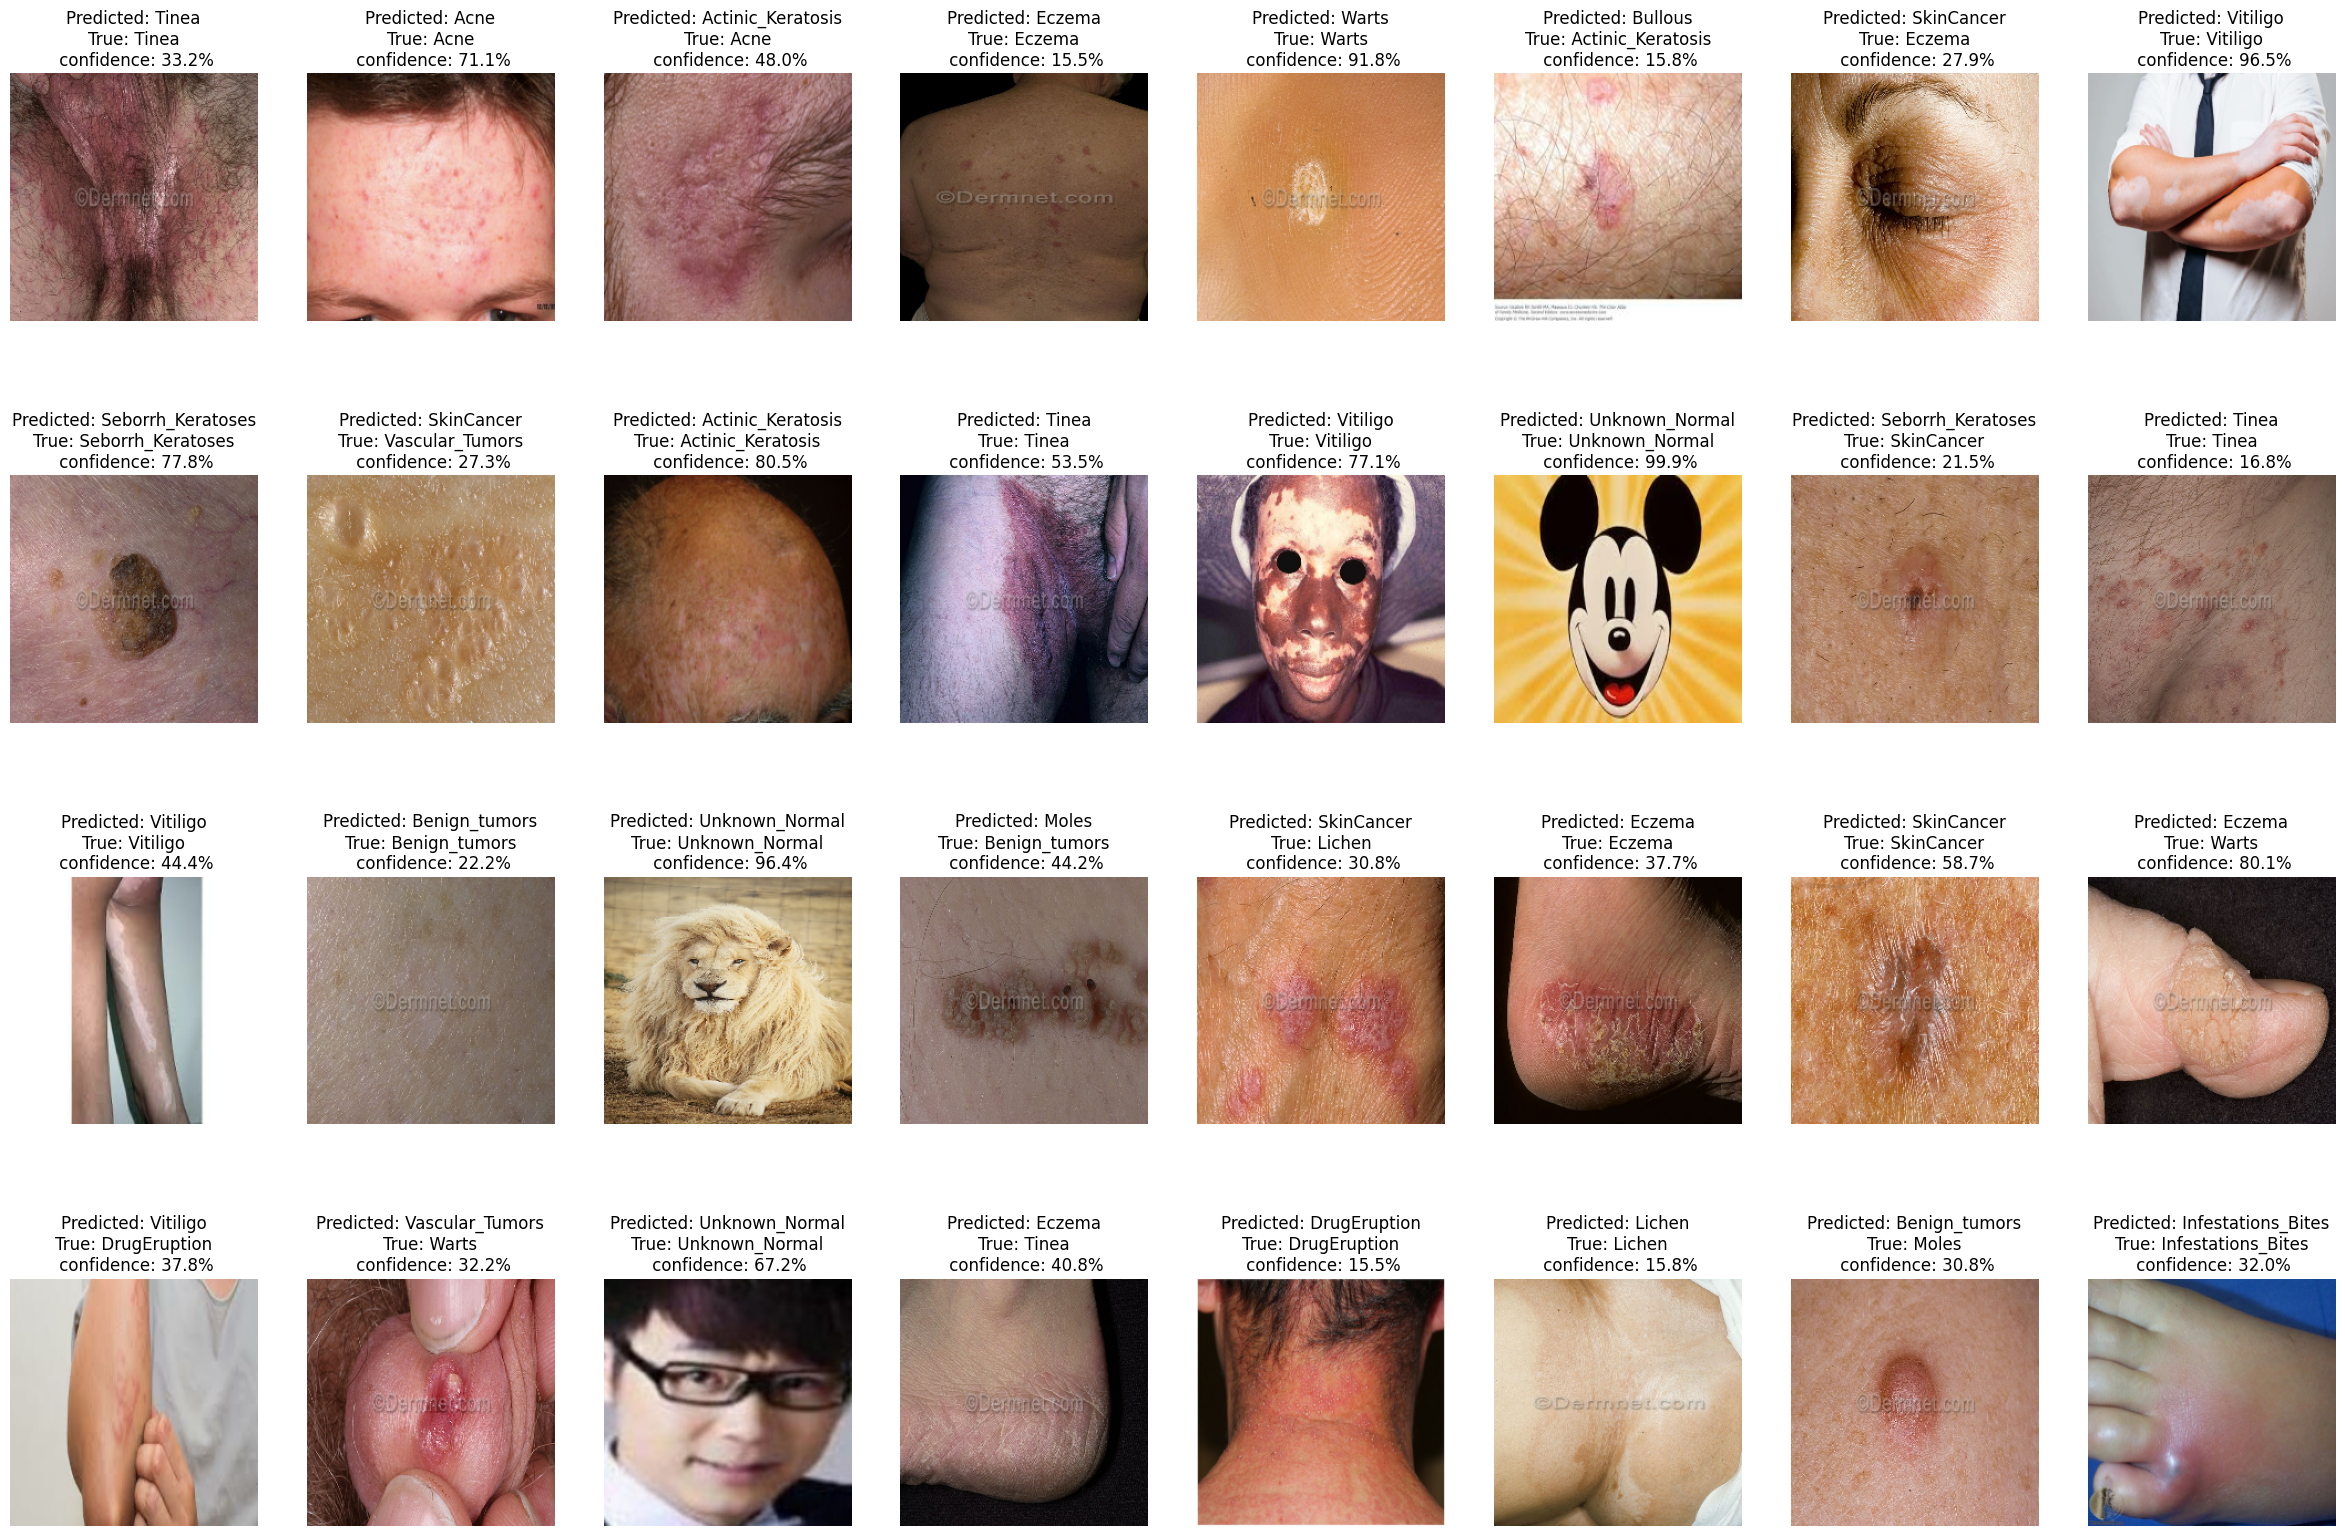

In [ ]:
plt.figure(figsize=(30, 20))
for images, labels in test_ds.take(1):
    prediction = new_model.predict(images)
    for i in range(32):
        pred_index = np.argmax(prediction[i])
        pred_label = class_names[pred_index]
        true_index = np.argmax(labels[i])
        true_label = class_names[true_index]
        confidence = np.max(prediction[i])*100

        plt.subplot(4, 8, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred L: {pred_label}\nTrue: {true_label}\n confi: {confidence:.1f}%')
        plt.axis('off')
plt.show()